In [1]:
import pandas as pd
import os
import numpy as np

In [2]:
os.getcwd()

'c:\\Users\\moham\\Downloads\\Projects\\Toxicity_Prediction'

In [3]:
CLINICAL_PATH = "C:\\Users\\moham\\Downloads\\Projects\\Toxicity_Prediction\\Datasets"
file_path = os.path.join(CLINICAL_PATH, "Clinical_Data.xlsx")
pd.ExcelFile(file_path).sheet_names
clinical_data = pd.read_excel(os.path.join(CLINICAL_PATH, "Clinical_Data.xlsx"), sheet_name="Sheet1")
clinical_data.head()

,Unnamed: 0,REFERENCE,(PTUMLOC) Localization of the Primary Tumor,(TNMT) Primary Tumor Clinical T Stage,(TNMN) Primary Tumor Clinical N Stage,(SEX) Gender,(AGECALC) Calculated Age,(SMOKST) Smoking Status,(ALCOHST) Alcohol Consumption,(SIGNYN) Exisiting Signs and Symptoms,...,Esophagus_Dnear-max,Mandible_Dmean,Mandible_Dnear-max,Oral_Cavity_Dmean,Oral_Cavity_Dnear-max,PCM_(constrictors)_Dmean,Parotid_L_Dmean,Parotid_R_Dmean,Submandibular_gland_L_Dmean,Submandibular_gland_R_Dmean
0,0,001-001,3,6,5,1,55,3,2.0,1,...,44.933079,42.506419,63.429567,55.177622,73.326878,66.131530,21.449886,25.292695,63.399067,58.613570
1,1,001-002,1,3,3,1,69,3,3.0,1,...,54.976801,28.536961,44.323819,31.894954,60.076696,59.345385,23.712885,21.662136,49.643464,49.713957
2,2,001-003,0,5,4,1,65,2,2.0,1,...,53.395533,34.362538,51.877566,35.567644,50.120304,54.478619,24.633069,23.710518,51.503175,60.617270
3,3,001-004,3,6,5,1,64,2,3.0,1,...,44.975404,27.864552,51.535635,38.296340,72.138956,53.951102,16.941200,15.269222,52.738425,61.795604
4,4,001-005,3,3,6,1,47,3,3.0,1,...,47.133714,41.193861,68.135148,51.938374,72.673661,54.119922,64.182309,35.372785,68.379630,50.058246


In [4]:
clinical_data.columns

Index(['Unnamed: 0', 'REFERENCE',
       '(PTUMLOC) Localization of the Primary Tumor',
       '(TNMT) Primary Tumor Clinical T Stage',
       '(TNMN) Primary Tumor Clinical N Stage', '(SEX) Gender',
       '(AGECALC) Calculated Age', '(SMOKST) Smoking Status',
       '(ALCOHST) Alcohol Consumption',
       '(SIGNYN) Exisiting Signs and Symptoms',
       '(MHYN) Medical Oncological Significant History',
       '(IMRTHPTV) Total Dose Received in Gy', 'chemo_fit', 'avelumab_given',
       'chemo_unfit', 'PFS_event', 'PFS_duration_m', 'Dysphagia_binary',
       'Dermatitis_binary', 'Drymouth_binary', 'Oralpain_binary',
       'Mucositis_binary', 'BMI', 'Dose_per_fraction', 'Esophagus_Dmean',
       'Esophagus_Dnear-max', 'Mandible_Dmean', 'Mandible_Dnear-max',
       'Oral_Cavity_Dmean', 'Oral_Cavity_Dnear-max',
       'PCM_(constrictors)_Dmean', 'Parotid_L_Dmean', 'Parotid_R_Dmean',
       'Submandibular_gland_L_Dmean', 'Submandibular_gland_R_Dmean'],
      dtype='object')

In [5]:
rename_map = {
    'REFERENCE': 'patient_id',
    '(PTUMLOC) Localization of the Primary Tumor': 'tumour_loc',
    '(TNMT) Primary Tumor Clinical T Stage': 't_stage',
    '(TNMN) Primary Tumor Clinical N Stage': 'n_stage',
    '(SEX) Gender': 'sex',
    '(AGECALC) Calculated Age': 'age',
    '(SMOKST) Smoking Status': 'smoking',
    '(ALCOHST) Alcohol Consumption': 'alcohol',
    '(SIGNYN) Exisiting Signs and Symptoms': 'signs_symptoms',
    '(MHYN) Medical Oncological Significant History': 'medical_history',
    '(IMRTHPTV) Total Dose Received in Gy': 'total_dose_gy',
    'chemo_fit': 'chemo_fit',
    'avelumab_given': 'avelumab',
    'chemo_unfit': 'chemo_unfit',
    'BMI': 'bmi',
    'Dose_per_fraction': 'dose_per_fraction',
    'PFS_event': 'pfs_event',
    'PFS_duration_m': 'pfs_duration_m',
    'Dysphagia_binary': 'dysphagia',
    'Dermatitis_binary': 'dermatitis',
    'Drymouth_binary': 'drymouth',
    'Oralpain_binary': 'oralpain',
    'Mucositis_binary': 'mucositis',
    'Esophagus_Dmean': 'esophagus_dmean',
    'Esophagus_Dnear-max': 'esophagus_dnearmax',
    'Mandible_Dmean': 'mandible_dmean',
    'Mandible_Dnear-max': 'mandible_dnearmax',
    'Oral_Cavity_Dmean': 'oral_cavity_dmean',
    'Oral_Cavity_Dnear-max': 'oral_cavity_dnearmax',
    'PCM_(constrictors)_Dmean': 'pcm_dmean',
    'Parotid_L_Dmean': 'parotid_l_dmean',
    'Parotid_R_Dmean': 'parotid_r_dmean',
    'Submandibular_gland_L_Dmean': 'submandibular_l_dmean',
    'Submandibular_gland_R_Dmean': 'submandibular_r_dmean',
}

df = clinical_data.drop(columns=['Unnamed: 0'])
df = df.rename(columns=rename_map)

print("New shape:", df.shape)
print("\nColumns:")
print(list(df.columns))

New shape: (684, 34)

Columns:
['patient_id', 'tumour_loc', 't_stage', 'n_stage', 'sex', 'age', 'smoking', 'alcohol', 'signs_symptoms', 'medical_history', 'total_dose_gy', 'chemo_fit', 'avelumab', 'chemo_unfit', 'pfs_event', 'pfs_duration_m', 'dysphagia', 'dermatitis', 'drymouth', 'oralpain', 'mucositis', 'bmi', 'dose_per_fraction', 'esophagus_dmean', 'esophagus_dnearmax', 'mandible_dmean', 'mandible_dnearmax', 'oral_cavity_dmean', 'oral_cavity_dnearmax', 'pcm_dmean', 'parotid_l_dmean', 'parotid_r_dmean', 'submandibular_l_dmean', 'submandibular_r_dmean']


In [6]:
df.dtypes

patient_id                object
tumour_loc                 int64
t_stage                    int64
n_stage                    int64
sex                        int64
age                        int64
smoking                    int64
alcohol                  float64
signs_symptoms             int64
medical_history             bool
total_dose_gy            float64
chemo_fit                  int64
avelumab                   int64
chemo_unfit                int64
pfs_event                  int64
pfs_duration_m             int64
dysphagia                  int64
dermatitis                 int64
drymouth                   int64
oralpain                   int64
mucositis                  int64
bmi                      float64
dose_per_fraction        float64
esophagus_dmean          float64
esophagus_dnearmax       float64
mandible_dmean           float64
mandible_dnearmax        float64
oral_cavity_dmean        float64
oral_cavity_dnearmax     float64
pcm_dmean                float64
parotid_l_

Non-numeric columns: ['patient_id']
patient_id    object
dtype: object


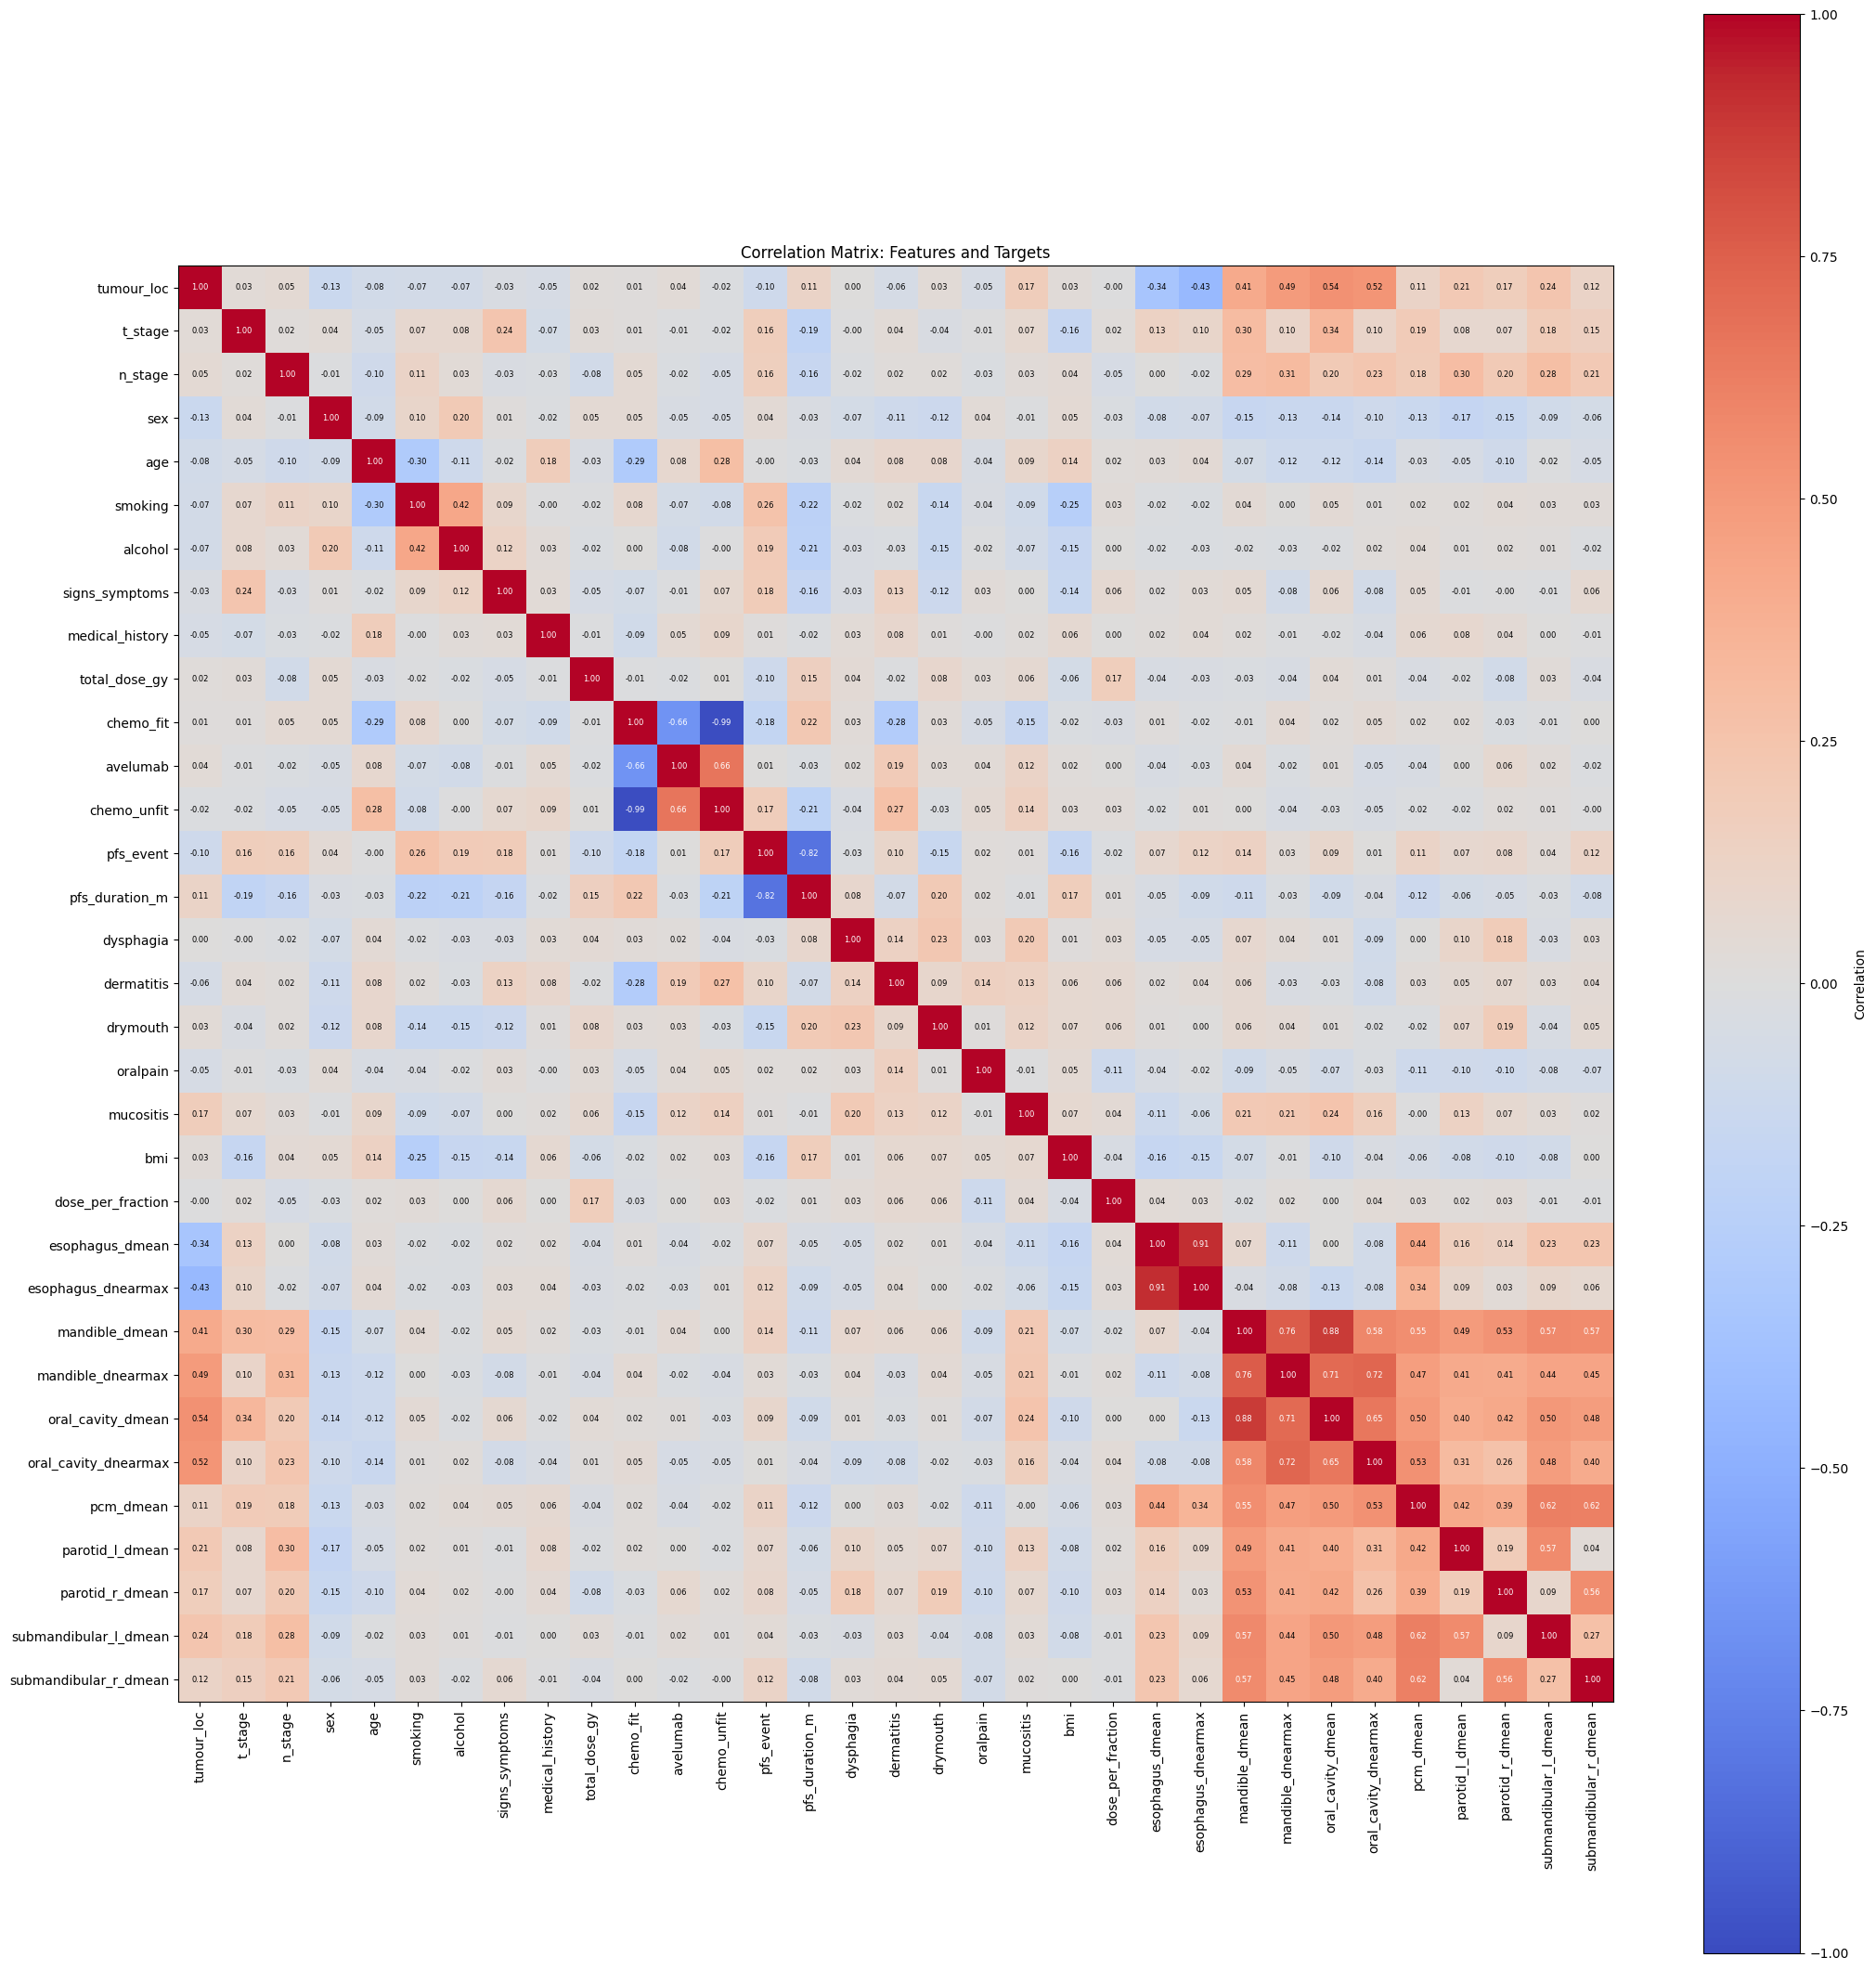

In [7]:
boolean_columns = df.select_dtypes(include='bool').columns
df[boolean_columns] = df[boolean_columns].astype(int)

non_numeric_columns = df.select_dtypes(exclude='number').columns
print("Non-numeric columns:", list(non_numeric_columns))
print(df[non_numeric_columns].dtypes)

# The categorical columns are already numerically encoded in the source data.
# Binary columns use 0/1; alcohol and smoking use ordered codes 1/2/3.
features_targets = df.drop(columns='patient_id')
correlation_matrix = features_targets.corr()

import matplotlib.pyplot as plt

column_names = correlation_matrix.columns
figure_size = max(16, len(column_names) * 0.65)
fig, axis = plt.subplots(figsize=(figure_size, figure_size))
image = axis.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)

axis.set_xticks(range(len(column_names)))
axis.set_yticks(range(len(column_names)))
axis.set_xticklabels(column_names, rotation=90)
axis.set_yticklabels(column_names)
axis.set_title('Correlation Matrix: Features and Targets')

for row_index in range(len(column_names)):
    for column_index in range(len(column_names)):
        value = correlation_matrix.iloc[row_index, column_index]
        text_color = 'white' if abs(value) >= 0.55 else 'black'
        axis.text(
            column_index,
            row_index,
            f'{value:.2f}',
            ha='center',
            va='center',
            color=text_color,
            fontsize=6,
        )

fig.colorbar(image, ax=axis, label='Correlation')
fig.tight_layout()
plt.show()

In [8]:
features_to_remove = [
    'chemo_unfit',
    'esophagus_dnearmax',
    'oral_cavity_dmean',
    'pfs_duration_m',
]

target_columns = [
    'mucositis',
    'drymouth',
    'dysphagia',
    'oralpain',
    'dermatitis',
    'pfs_event',
    'pfs_duration_m',
]

model_df = df.drop(columns=features_to_remove)
targets_df = model_df[['patient_id'] + [column for column in target_columns if column in model_df.columns]]
features_df = model_df.drop(columns=target_columns, errors='ignore')

assert features_df['patient_id'].equals(targets_df['patient_id'])

features_path = os.path.join(CLINICAL_PATH, 'Clinical_Features.xlsx')
targets_path = os.path.join(CLINICAL_PATH, 'Clinical_Targets.xlsx')
features_df.to_excel(features_path, index=False)
targets_df.to_excel(targets_path, index=False)

print(f'Features saved to: {features_path}')
print(f'Targets saved to: {targets_path}')
print(f'Features shape: {features_df.shape}')
print(f'Targets shape: {targets_df.shape}')
print(f'Feature columns: {list(features_df.columns)}')
print(f'Target columns: {list(targets_df.columns)}')
print('Patient IDs match in both files: True')

Features saved to: C:\Users\moham\Downloads\Projects\Toxicity_Prediction\Datasets\Clinical_Features.xlsx
Targets saved to: C:\Users\moham\Downloads\Projects\Toxicity_Prediction\Datasets\Clinical_Targets.xlsx
Features shape: (684, 24)
Targets shape: (684, 7)
Feature columns: ['patient_id', 'tumour_loc', 't_stage', 'n_stage', 'sex', 'age', 'smoking', 'alcohol', 'signs_symptoms', 'medical_history', 'total_dose_gy', 'chemo_fit', 'avelumab', 'bmi', 'dose_per_fraction', 'esophagus_dmean', 'mandible_dmean', 'mandible_dnearmax', 'oral_cavity_dnearmax', 'pcm_dmean', 'parotid_l_dmean', 'parotid_r_dmean', 'submandibular_l_dmean', 'submandibular_r_dmean']
Target columns: ['patient_id', 'mucositis', 'drymouth', 'dysphagia', 'oralpain', 'dermatitis', 'pfs_event']
Patient IDs match in both files: True


In [9]:
Clinical_Features = pd.read_excel(features_path)
Clinical_Targets = pd.read_excel(targets_path)

assert Clinical_Features['patient_id'].equals(Clinical_Targets['patient_id'])

Clinical_Features.columns

Index(['patient_id', 'tumour_loc', 't_stage', 'n_stage', 'sex', 'age',
       'smoking', 'alcohol', 'signs_symptoms', 'medical_history',
       'total_dose_gy', 'chemo_fit', 'avelumab', 'bmi', 'dose_per_fraction',
       'esophagus_dmean', 'mandible_dmean', 'mandible_dnearmax',
       'oral_cavity_dnearmax', 'pcm_dmean', 'parotid_l_dmean',
       'parotid_r_dmean', 'submandibular_l_dmean', 'submandibular_r_dmean'],
      dtype='object')

In [10]:
TARGET = 'drymouth'

X = Clinical_Features.drop(columns='patient_id')
y = Clinical_Targets[TARGET]

print("X shape:", X.shape)
print("y distribution:\n", y.value_counts(normalize=True))

X shape: (684, 23)
y distribution:
 drymouth
0    0.618421
1    0.381579
Name: proportion, dtype: float64


In [11]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from tabpfn import TabPFNClassifier

N_SPLITS = 5
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

tabpfn_clf = TabPFNClassifier(random_state=42)

scoring = ['accuracy', 'balanced_accuracy', 'roc_auc', 'f1']

cv_results = cross_validate(
    tabpfn_clf, X, y,
    cv=cv,
    scoring=scoring,
    n_jobs=1,
    return_train_score=False,
)

print(f"TabPFN {N_SPLITS}-fold stratified CV results for target='{TARGET}':\n")
for metric in scoring:
    scores = cv_results[f'test_{metric}']
    print(f"  {metric:18s}: {scores.mean():.3f} +/- {scores.std():.3f}  (folds: {np.round(scores, 3)})")

TabPFN 5-fold stratified CV results for target='drymouth':

  accuracy          : 0.648 +/- 0.023  (folds: [0.679 0.613 0.657 0.657 0.632])
  balanced_accuracy : 0.577 +/- 0.016  (folds: [0.592 0.558 0.597 0.581 0.56 ])
  roc_auc           : 0.660 +/- 0.050  (folds: [0.709 0.566 0.671 0.695 0.657])
  f1                : 0.375 +/- 0.034  (folds: [0.353 0.391 0.434 0.356 0.342])


In [13]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from lightgbm import LGBMClassifier

target = 'drymouth'

# --- column groups ---
continuous = ['age','bmi','total_dose_gy','dose_per_fraction',
              'esophagus_dmean','esophagus_dnearmax','mandible_dmean','mandible_dnearmax',
              'oral_cavity_dmean','oral_cavity_dnearmax','pcm_dmean',
              'parotid_l_dmean','parotid_r_dmean','submandibular_l_dmean','submandibular_r_dmean']
ordinal    = ['t_stage','n_stage']
nominal    = ['tumour_loc','sex','smoking','alcohol','signs_symptoms']

continuous = [c for c in continuous if c in df.columns]
ordinal    = [c for c in ordinal if c in df.columns]
nominal    = [c for c in nominal if c in df.columns]

X = df[continuous + ordinal + nominal].copy()
y = df[target].astype(int)

# --- preprocessing for the linear model ---
pre = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                      ('sc', StandardScaler())]), continuous + ordinal),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('oh', OneHotEncoder(handle_unknown='ignore'))]), nominal),
])

enet = Pipeline([('pre', pre),
                 ('clf', LogisticRegression(penalty='elasticnet', solver='saga',
                                            l1_ratio=0.5, C=1.0, class_weight='balanced',
                                            max_iter=5000))])

# --- GBDT: trees handle raw features + NaN natively, no scaling/encoding needed ---
gbm = LGBMClassifier(n_estimators=400, learning_rate=0.03, num_leaves=15,
                     subsample=0.8, colsample_bytree=0.8, class_weight='balanced',
                     random_state=0, verbose=-1)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['roc_auc', 'balanced_accuracy', 'f1']
model_cv_results = {'TabPFN': cv_results}

for name, model, data in [('Elastic net', enet, X), ('LightGBM', gbm, X)]:
    results = cross_validate(model, data, y, cv=cv, scoring=scoring)
    model_cv_results[name] = results
    print(f"\n{name}")
    for metric in scoring:
        scores = results['test_' + metric]
        print(f"  {metric:18s}: {scores.mean():.3f} +/- {scores.std():.3f}")

c:\Users\moham\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\moham\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\moham\miniconda3\Lib\site-packages\sklearn\linear


Elastic net
  roc_auc           : 0.642 +/- 0.042
  balanced_accuracy : 0.583 +/- 0.028
  f1                : 0.504 +/- 0.036

LightGBM
  roc_auc           : 0.617 +/- 0.042
  balanced_accuracy : 0.572 +/- 0.021
  f1                : 0.469 +/- 0.011


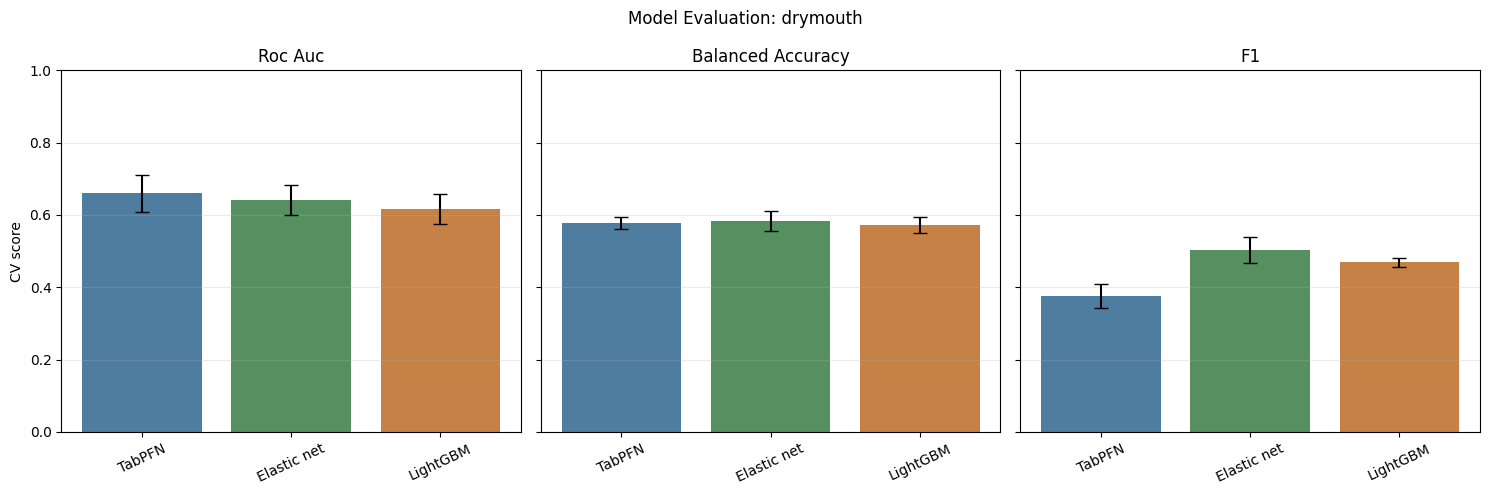

In [14]:
import numpy as np
import matplotlib.pyplot as plt

plot_metrics = ['roc_auc', 'balanced_accuracy', 'f1']
model_names = list(model_cv_results)
means = np.array([
    [model_cv_results[name]['test_' + metric].mean() for metric in plot_metrics]
    for name in model_names
])
stds = np.array([
    [model_cv_results[name]['test_' + metric].std() for metric in plot_metrics]
    for name in model_names
])

fig, axes = plt.subplots(1, len(plot_metrics), figsize=(15, 5), sharey=True)
colors = ['#2f6690', '#3a7d44', '#bc6c25']

for index, metric in enumerate(plot_metrics):
    axes[index].bar(model_names, means[:, index], yerr=stds[:, index],
                    capsize=5, color=colors[:len(model_names)], alpha=0.85)
    axes[index].set_title(metric.replace('_', ' ').title())
    axes[index].set_ylim(0, 1)
    axes[index].tick_params(axis='x', rotation=25)
    axes[index].grid(axis='y', alpha=0.25)
    axes[index].set_ylabel('CV score' if index == 0 else '')

fig.suptitle(f'Model Evaluation: {target}')
fig.tight_layout()
plt.show()